In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from piemd import PIEMD, Source, Deflector, DiskSource
import scipy as sp
from PIL import Image

# Testing Gaussian psf vs Hubble psf from literature

100.0


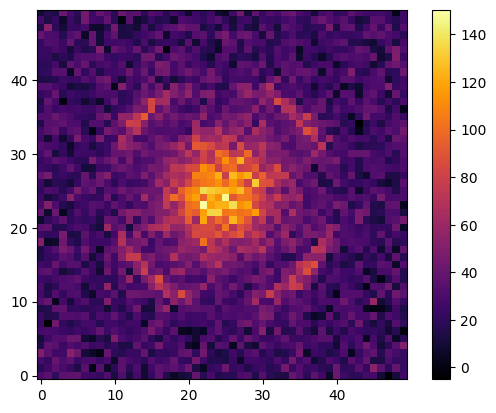

In [2]:
src = DiskSource(1000, 10)
df = PIEMD(src, theta_E=300, q=0.9, phi=np.pi/4, s=10)

img = df.generate_hubble_image(psf='gaussian', lens='gaussian')
plt.imshow(img, cmap='inferno', origin='lower')
plt.colorbar()
plt.show()

100.0


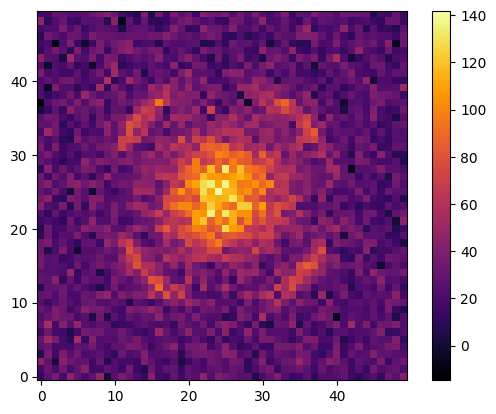

In [3]:
src = DiskSource(1000, 10)
df = PIEMD(src, theta_E=300, q=0.9, phi=np.pi/4, s=10)

img = df.generate_hubble_image(psf='hubble', lens='gaussian')
plt.imshow(img, cmap='inferno', origin='lower')
plt.colorbar()
plt.show()

# Testing Sercic vs Gaussian Profiles

100.0


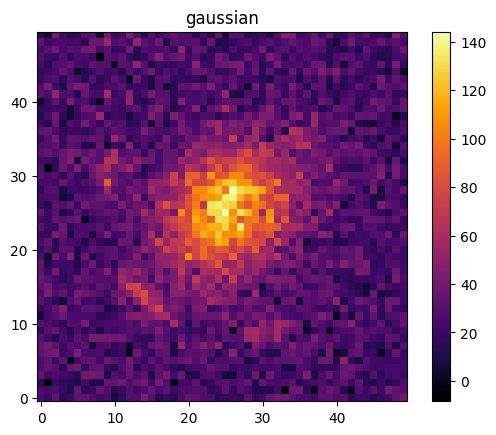

100.0


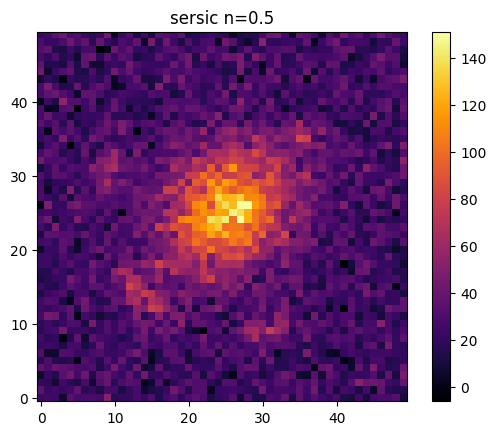

100.0


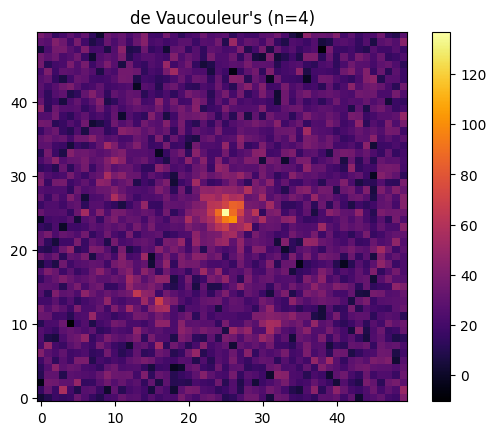

100.0


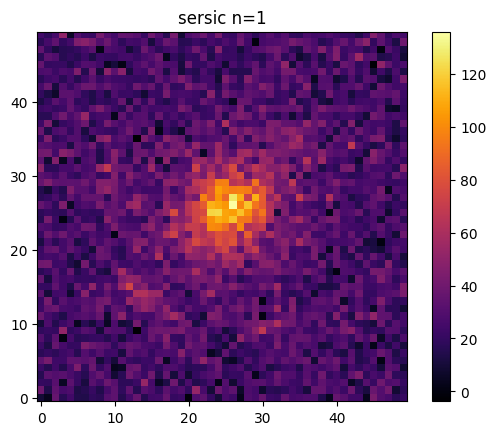

In [4]:
src = DiskSource(1000, 10)
df = PIEMD(src, theta_E=300, q=0.8, phi=np.pi/4, s=10)
df.align_lens(cx=515, cy=515)

# gaussian
img = df.generate_hubble_image(psf='hubble', n=2, lens='gaussian')
plt.imshow(img, cmap='inferno', origin='lower')
plt.colorbar()
plt.title("gaussian")
plt.show()

# should be the same distribution as gaussian
img = df.generate_hubble_image(psf='hubble', lens='sersic', R_e=120, n=0.5, I_lens=0.5)
plt.imshow(img, cmap='inferno', origin='lower')
plt.colorbar()
plt.title("sersic n=0.5")
plt.show()

# de Vaucouleur's
img = df.generate_hubble_image(psf='hubble', lens='sersic', R_e=120, n=4, I_lens=0.1)
plt.imshow(img, cmap='inferno', origin='lower')
plt.title("de Vaucouleur's (n=4)")
plt.colorbar()
plt.show()

# something else
img = df.generate_hubble_image(psf='hubble', lens='sersic', R_e=120, n=1, I_lens=0.4)
plt.imshow(img, cmap='inferno', origin='lower')
plt.colorbar()
plt.title("sersic n=1")
plt.show()

# Now lets try a sersic core model
https://iopscience.iop.org/article/10.1086/382712/pdf

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

In [6]:
# src = DiskSource(1000, 10)
df = PIEMD(src, theta_E=400, q=0.8, phi=np.pi/4, s=50)
df.align_source(cx=473, cy=525)

100.0


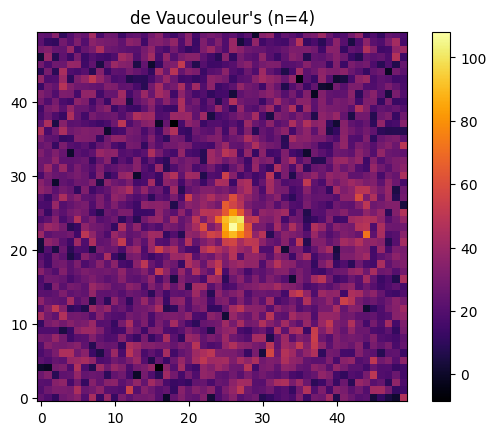

100.0


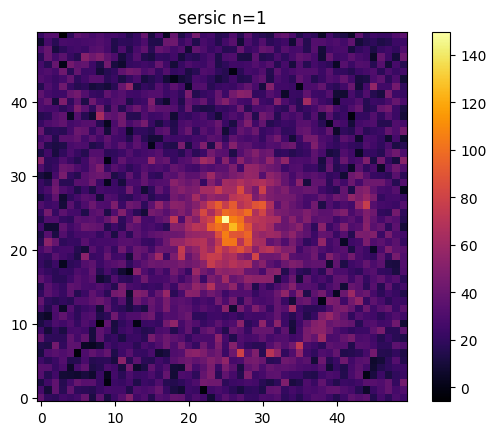

100.0


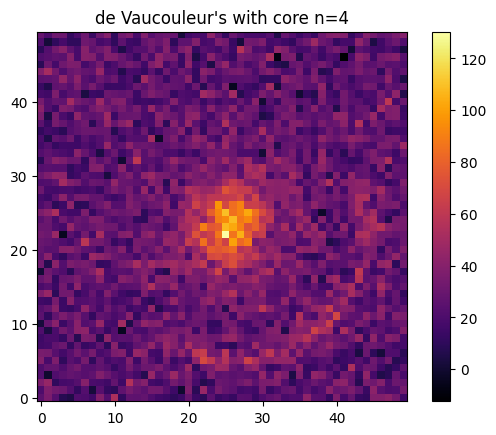

100.0


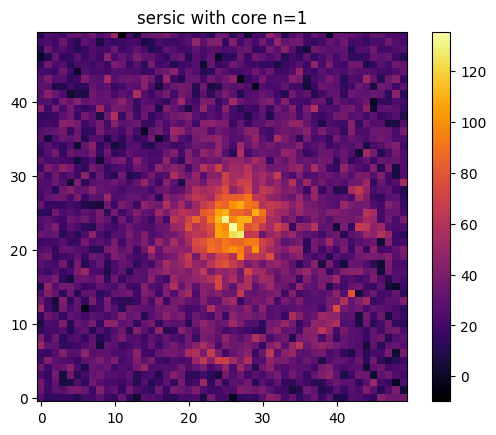

In [7]:
# de Vaucouleur's
img = df.generate_hubble_image(psf='hubble', lens='sersic', R_e=120, n=4, I_lens=0.1)
plt.imshow(img, cmap='inferno', origin='lower')
plt.title("de Vaucouleur's (n=4)")
plt.colorbar()
plt.show()

# something else
img = df.generate_hubble_image(psf='hubble', lens='sersic', R_e=120, n=1, I_lens=0.4)
plt.imshow(img, cmap='inferno', origin='lower')
plt.colorbar()
plt.title("sersic n=1")
plt.show()

# de Vaucouleur's with core
img = df.generate_hubble_image(psf='hubble', lens='sersic_core', R_e=120, n=4, I_lens=1, R_b=50)
plt.imshow(img, cmap='inferno', origin='lower')
plt.colorbar()
plt.title("de Vaucouleur's with core n=4")
plt.savefig("de_v_core.png")
plt.show()

# something else with core
img = df.generate_hubble_image(psf='hubble', lens='sersic_core', R_e=120, n=1, I_lens=1)
plt.imshow(img, cmap='inferno', origin='lower')
plt.colorbar()
plt.title("sersic with core n=1")
plt.show()



# What about a double source plane?

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt

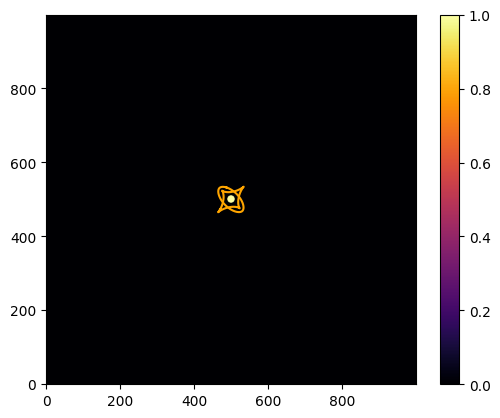

In [9]:
src1 = DiskSource(1000, 10)
df1 = PIEMD(src1, theta_E=100, s=30, q=0.6, phi=np.pi/4)
df1.plot_source(caustics=True)

In [10]:
%matplotlib inline
import matplotlib.pyplot as plt

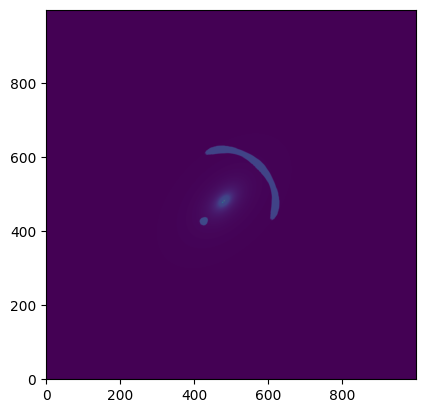

In [11]:
src1 = DiskSource(1000, 10)
df1 = PIEMD(src1, theta_E=100, s=10, q=0.6, phi=np.pi/4)
df1.align_source(518,518)
arr2 = df1.generate_image(lens='sersic_core')
plt.imshow(arr2, origin='lower')
plt.show()

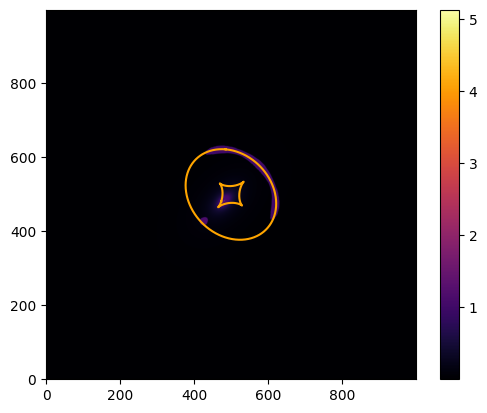

In [12]:
df2 = PIEMD(Source(arr2), theta_E=280, s=40, q=0.8, phi=np.pi/4)
df2.plot_source(caustics=True)

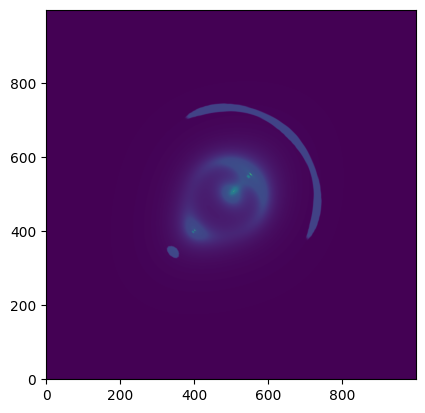

In [13]:
df2 = PIEMD(Source(arr2), theta_E=110, s=20, q=0.8, phi=-np.pi/4)
arr3 = df2.generate_image(lens='sersic_core')
plt.imshow(arr3, origin='lower')
plt.savefig("figures_out/double_lens.png")
plt.show()

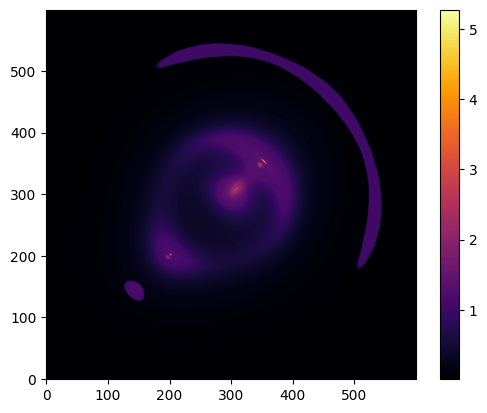

In [14]:
arr3 = arr3[200:800,200:800]
plt.imshow(arr3, origin='lower', cmap='inferno')
plt.colorbar()
plt.show()
df2.set_image(arr3)

100.0


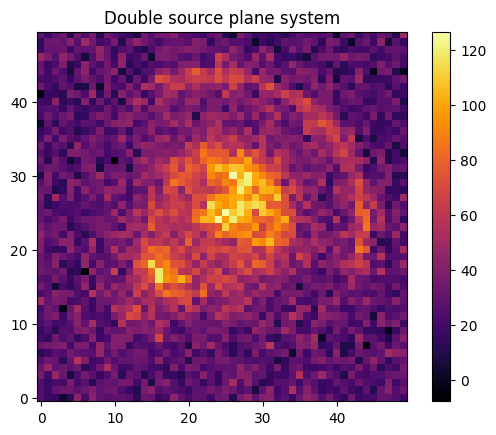

In [15]:
img = df2.generate_hubble_image(psf='hubble', lens='none', R_e=50, n=4, I_lens=1)
plt.imshow(img, cmap='inferno', origin='lower')
plt.colorbar()
plt.title("Double source plane system")
plt.show()

# Lets try another

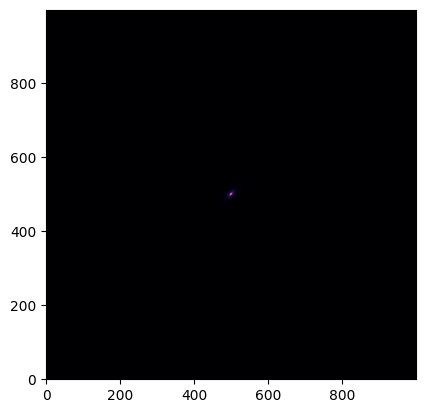

In [16]:
df1 = PIEMD(Source(np.zeros((1000,1000))), theta_E=10, q=0.5, s=1, phi=np.pi/4)
img1 = df1.generate_image(lens='sersic_core')

plt.imshow(img1, origin='lower', cmap='inferno')
plt.savefig("figures_out/source1.png")
plt.show()

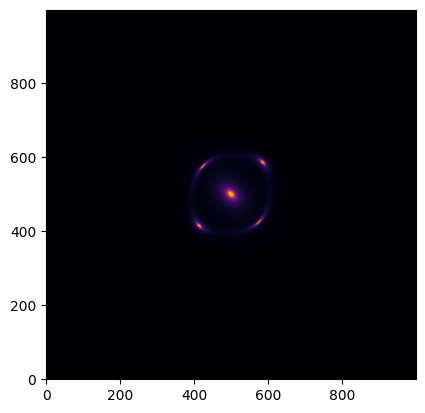

In [17]:
src2 = Source(img1)
df2 = PIEMD(src2, theta_E=100, q=0.7, s=5, phi=-np.pi/4)

img2 = df2.generate_image(lens='sersic_core')

plt.imshow(img2, origin='lower', cmap='inferno')
plt.savefig("figures_out/source2.png")
plt.show()

In [18]:
%matplotlib inline
import matplotlib.pyplot as plt

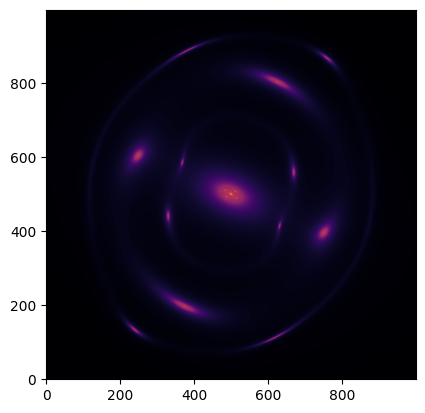

In [19]:
src3 = Source(img2)
df3 = PIEMD(src3, theta_E=250, q=0.6, s=20, phi=-np.pi/8)
# df3.align_source()
img3 = df3.generate_image(lens='sersic_core')

plt.imshow(img3, origin='lower', cmap='inferno')
plt.savefig("figures_out/final_lens.png")
plt.show()

100.0


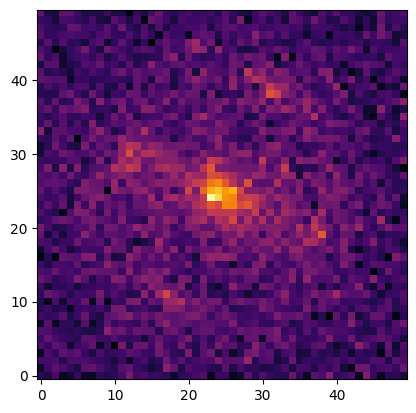

In [20]:
hubble_img = df3.generate_hubble_image(I_lens=0.01)

plt.imshow(hubble_img, origin='lower', cmap='inferno')
plt.show()

In [28]:
import numpy as np

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
from piemd import PIEMD, Deflector, Source
import scipy as sp
from PIL import Image

matplotlib.rcParams['image.origin'] = 'lower'
matplotlib.rcParams['image.cmap'] = 'inferno'
matplotlib.rcParams['figure.figsize'] = (7,7)

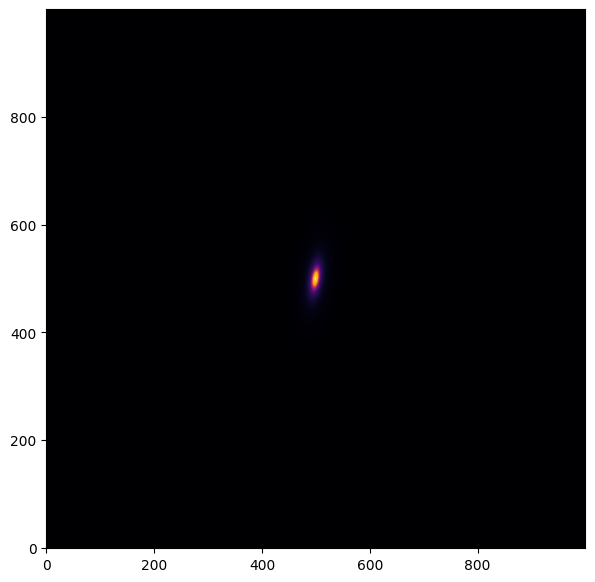

In [29]:
res = 1000
theta_E = 20
s = np.random.normal(5, 0.5)
q = np.random.uniform(0.1,1)
phi = np.random.uniform(0,2*np.pi)

df = PIEMD(
    source=Source(np.zeros((res,res))), 
    theta_E=theta_E, 
    s=s,
    q=q,
    phi=phi
    )

lens = df.generate_sersic_core_lens(
    n=4, 
    R_e = 0.5*theta_E,
    R_b = s,
    gamma = 0.1,
    alpha = 30
    )

plt.imshow(lens)
plt.show()

In [30]:
src = Source(lens)

theta_E=150
q = np.random.uniform(0.1, 1)
s = np.random.uniform(0.1*theta_E, 0.5*theta_E)
phi = np.random.uniform(0, 2*np.pi)

piemd = PIEMD(
    src, 
    theta_E=theta_E,
    q=q,
    s=s,
    phi=phi
    )

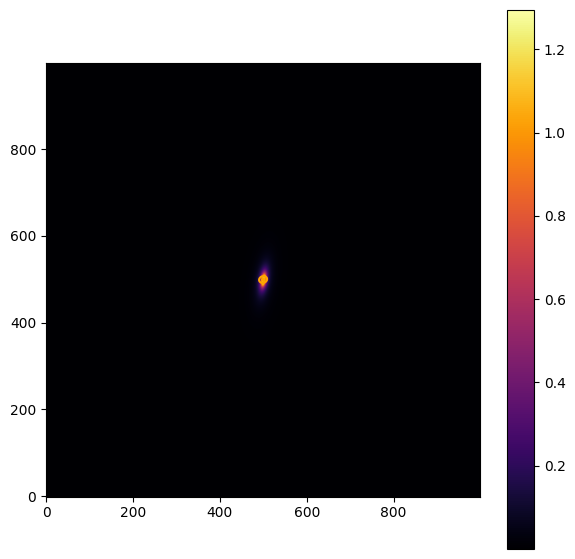

In [31]:
piemd.plot_source(caustics=True)

In [32]:
I_lens = 1
img_no_lens = piemd.generate_image(lens='none')
img = piemd.generate_image(lens='sersic_core', I_lens=I_lens)
hubble_img = piemd.generate_hubble_image(I_lens=I_lens)
euclid_img = piemd.generate_euclid_image(I_lens=I_lens)
jwst_img = piemd.generate_JWST_image(I_lens=I_lens)

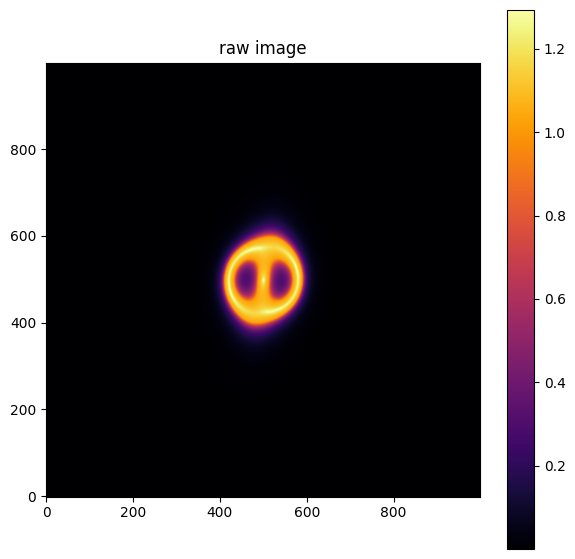

In [33]:
plt.imshow(img_no_lens)
plt.colorbar()
plt.title("raw image")
plt.show()

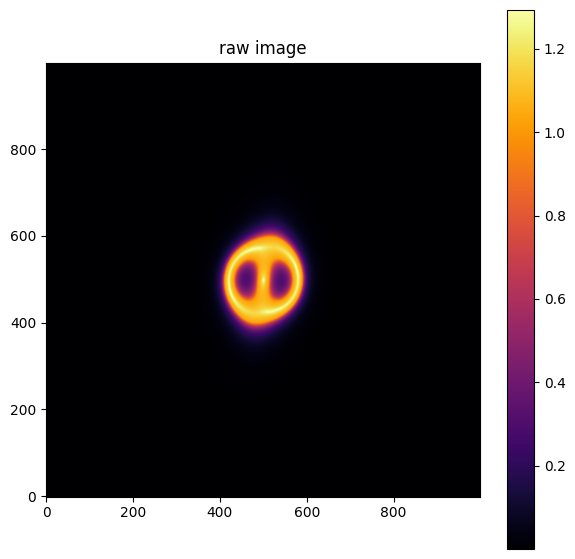

In [34]:
plt.imshow(img)
plt.colorbar()
plt.title("raw image")
plt.show()

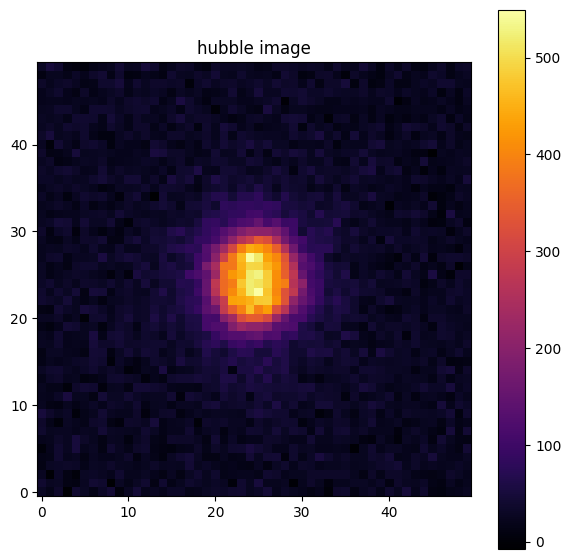

In [35]:
plt.imshow(hubble_img)
plt.colorbar()
plt.title("hubble image")
plt.show()

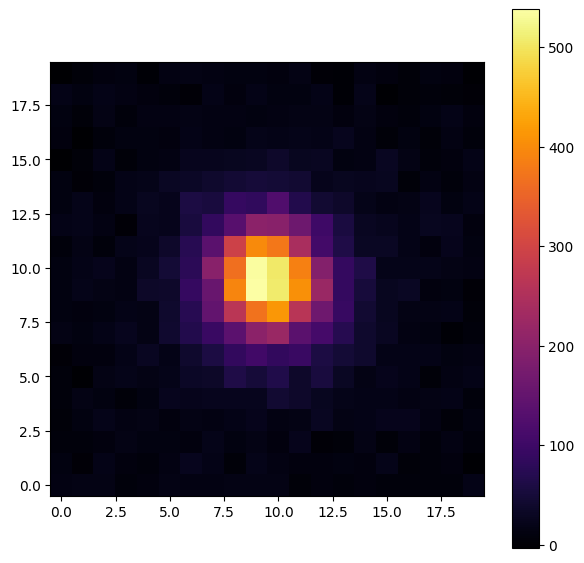

In [36]:
plt.imshow(euclid_img)
plt.colorbar()
plt.show()

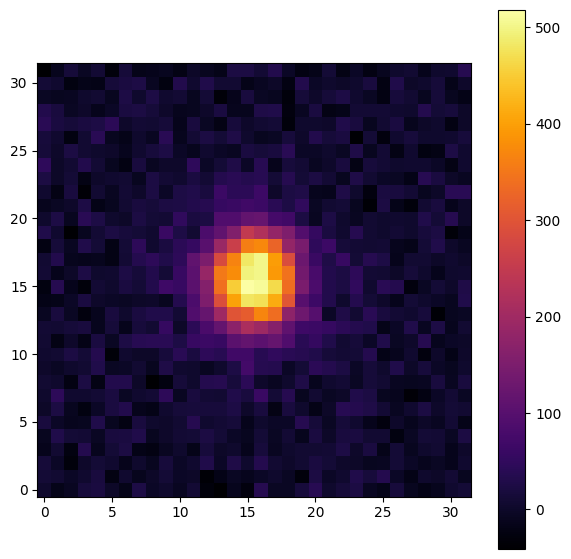

In [37]:
plt.imshow(jwst_img)
plt.colorbar()
plt.show()